In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


k = 2, Silhouette Score = 0.7075955632562002
k = 3, Silhouette Score = 0.7636008195603978
k = 4, Silhouette Score = 0.7843727073779272
k = 5, Silhouette Score = 0.7341393562942123
k = 6, Silhouette Score = 0.7339486206614896
k = 7, Silhouette Score = 0.6651657958270236
k = 8, Silhouette Score = 0.35981820370614603
k = 9, Silhouette Score = 0.3609708299841205
k = 10, Silhouette Score = 0.3565505233525243

Best k based on Silhouette Score: 4


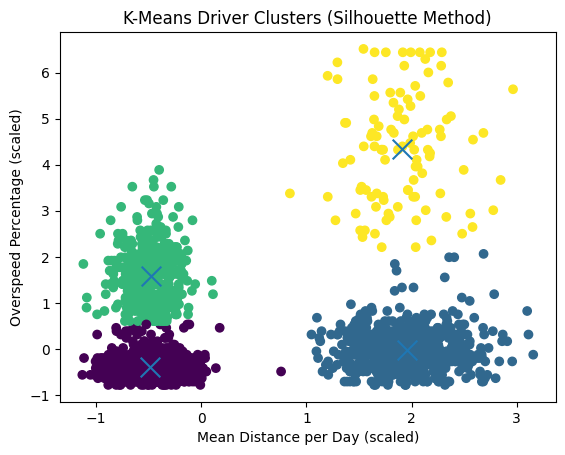

In [4]:
# K-Means clustering using Silhouette Score (no Elbow/WCSS) + Visualization

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# ---------------------------
# Load dataset
# ---------------------------
df = pd.read_csv("/content/drive/MyDrive/ML/driver-data.csv")

# Use the same columns from the CSV
X = df[['mean_dist_day', 'mean_over_speed_perc']]

# ---------------------------
# Scale features
# ---------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---------------------------
# Find best k using Silhouette Score
# ---------------------------
scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append(score)
    print(f"k = {k}, Silhouette Score = {score}")

best_k = K_range[scores.index(max(scores))]
print("\nBest k based on Silhouette Score:", best_k)

# ---------------------------
# Apply K-Means with best k
# ---------------------------
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

# ---------------------------
# Cluster Visualization
# ---------------------------
plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            marker='x', s=200)
plt.xlabel("Mean Distance per Day (scaled)")
plt.ylabel("Overspeed Percentage (scaled)")
plt.title("K-Means Driver Clusters (Silhouette Method)")
plt.show()